# RentSmart – Rental Price Prediction Project

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

## Load the Dataset

In [ ]:
train_df = pd.read_csv("track_a_rental_pricing_train.csv")
test_df = pd.read_csv("track_a_rental_pricing_test.csv")

## First Look at the Data

In [ ]:
train_df.shape

(800, 13)

In [ ]:
train_df.head()

,surface_m2,num_rooms,floor_number,has_elevator,building_age_years,distance_metro_km,district_prestige_score,has_parking,energy_rating,num_photos,construction_quality_score,distance_supermarket_m,rent_eur_month
0,96.9,5,12,0,66.3,2.521,2.96,0,2,3,30.2,372,1793.92
1,62.8,1,10,0,47.5,1.282,6.97,1,4,16,60.4,994,1475.52
2,105.6,2,14,0,19.6,2.989,7.90,0,1,18,83.3,181,1958.44
3,89.1,3,15,0,59.7,0.881,2.50,1,5,22,49.3,618,1874.20
4,27.6,4,11,1,6.8,1.907,1.39,1,3,18,97.7,954,1153.21


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   surface_m2                  800 non-null    float64
 1   num_rooms                   800 non-null    int64  
 2   floor_number                800 non-null    int64  
 3   has_elevator                800 non-null    int64  
 4   building_age_years          800 non-null    float64
 5   distance_metro_km           800 non-null    float64
 6   district_prestige_score     800 non-null    float64
 7   has_parking                 800 non-null    int64  
 8   energy_rating               800 non-null    int64  
 9   num_photos                  800 non-null    int64  
 10  construction_quality_score  800 non-null    float64
 11  distance_supermarket_m      800 non-null    int64  
 12  rent_eur_month              800 non-null    float64
dtypes: float64(6), int64(7)
memory usag

In [ ]:
train_df.describe()

,surface_m2,num_rooms,floor_number,has_elevator,building_age_years,distance_metro_km,district_prestige_score,has_parking,energy_rating,num_photos,construction_quality_score,distance_supermarket_m,rent_eur_month
count,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,68.428500,2.991250,7.50125,0.400000,40.069500,1.734011,5.419837,0.348750,2.975000,15.601250,63.914875,759.160000,1595.794038
std,29.631381,1.419927,4.56931,0.490204,23.363184,0.988580,2.602787,0.476873,1.428084,8.670422,22.121027,426.603974,362.921099
min,18.100000,1.000000,0.00000,0.000000,0.100000,0.053000,1.000000,0.000000,1.000000,1.000000,12.200000,50.000000,770.230000
25%,42.175000,2.000000,3.00000,0.000000,20.075000,0.883000,3.117500,0.000000,2.000000,8.000000,46.075000,381.500000,1308.345000
50%,68.250000,3.000000,7.00000,0.000000,40.500000,1.713000,5.385000,0.000000,3.000000,16.000000,64.650000,741.000000,1599.415000
75%,95.075000,4.000000,12.00000,1.000000,60.525000,2.583250,7.712500,1.000000,4.000000,23.000000,82.000000,1124.250000,1881.222500
max,119.900000,5.000000,15.00000,1.000000,80.000000,3.494000,9.990000,1.000000,5.000000,30.000000,100.000000,1499.000000,2475.740000


## Check Missing Values

In [ ]:
train_df.isnull().sum()

surface_m2                    0
num_rooms                     0
floor_number                  0
has_elevator                  0
building_age_years            0
distance_metro_km             0
district_prestige_score       0
has_parking                   0
energy_rating                 0
num_photos                    0
construction_quality_score    0
distance_supermarket_m        0
rent_eur_month                0
dtype: int64

In [ ]:
(train_df.isnull().sum() / len(train_df)) * 100

surface_m2                    0.0
num_rooms                     0.0
floor_number                  0.0
has_elevator                  0.0
building_age_years            0.0
distance_metro_km             0.0
district_prestige_score       0.0
has_parking                   0.0
energy_rating                 0.0
num_photos                    0.0
construction_quality_score    0.0
distance_supermarket_m        0.0
rent_eur_month                0.0
dtype: float64

## Target Variable Analysis

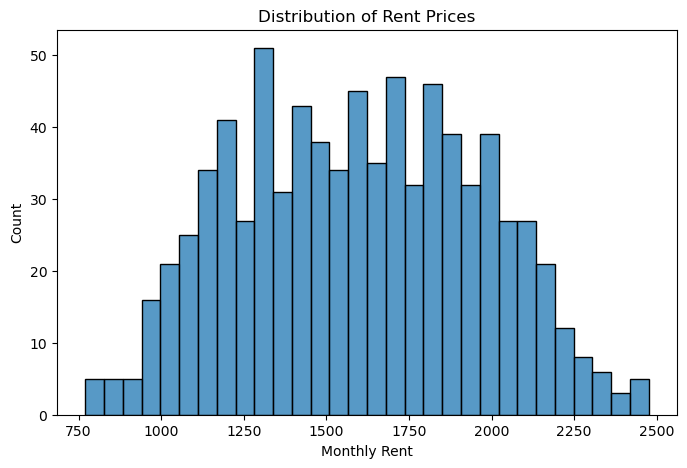

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(train_df["rent_eur_month"], bins=30)

plt.title("Distribution of Rent Prices")
plt.xlabel("Monthly Rent")
plt.ylabel("Count")

plt.show()

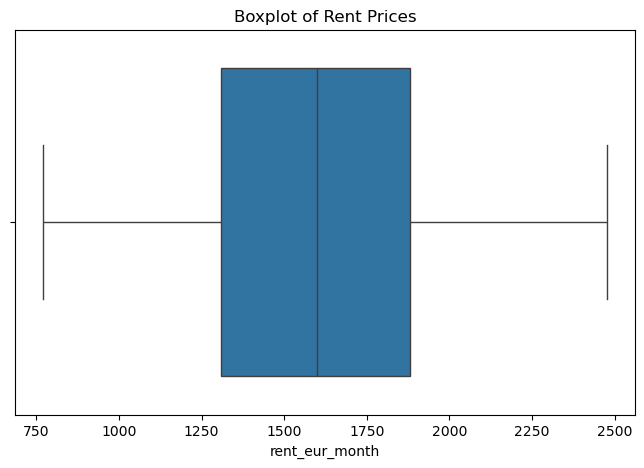

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=train_df["rent_eur_month"])

plt.title("Boxplot of Rent Prices")

plt.show()

## Numerical Features

In [ ]:
numerical_columns = train_df.select_dtypes(include=np.number).columns
numerical_columns

Index(['surface_m2', 'num_rooms', 'floor_number', 'has_elevator',
       'building_age_years', 'distance_metro_km', 'district_prestige_score',
       'has_parking', 'energy_rating', 'num_photos',
       'construction_quality_score', 'distance_supermarket_m',
       'rent_eur_month'],
      dtype='object')

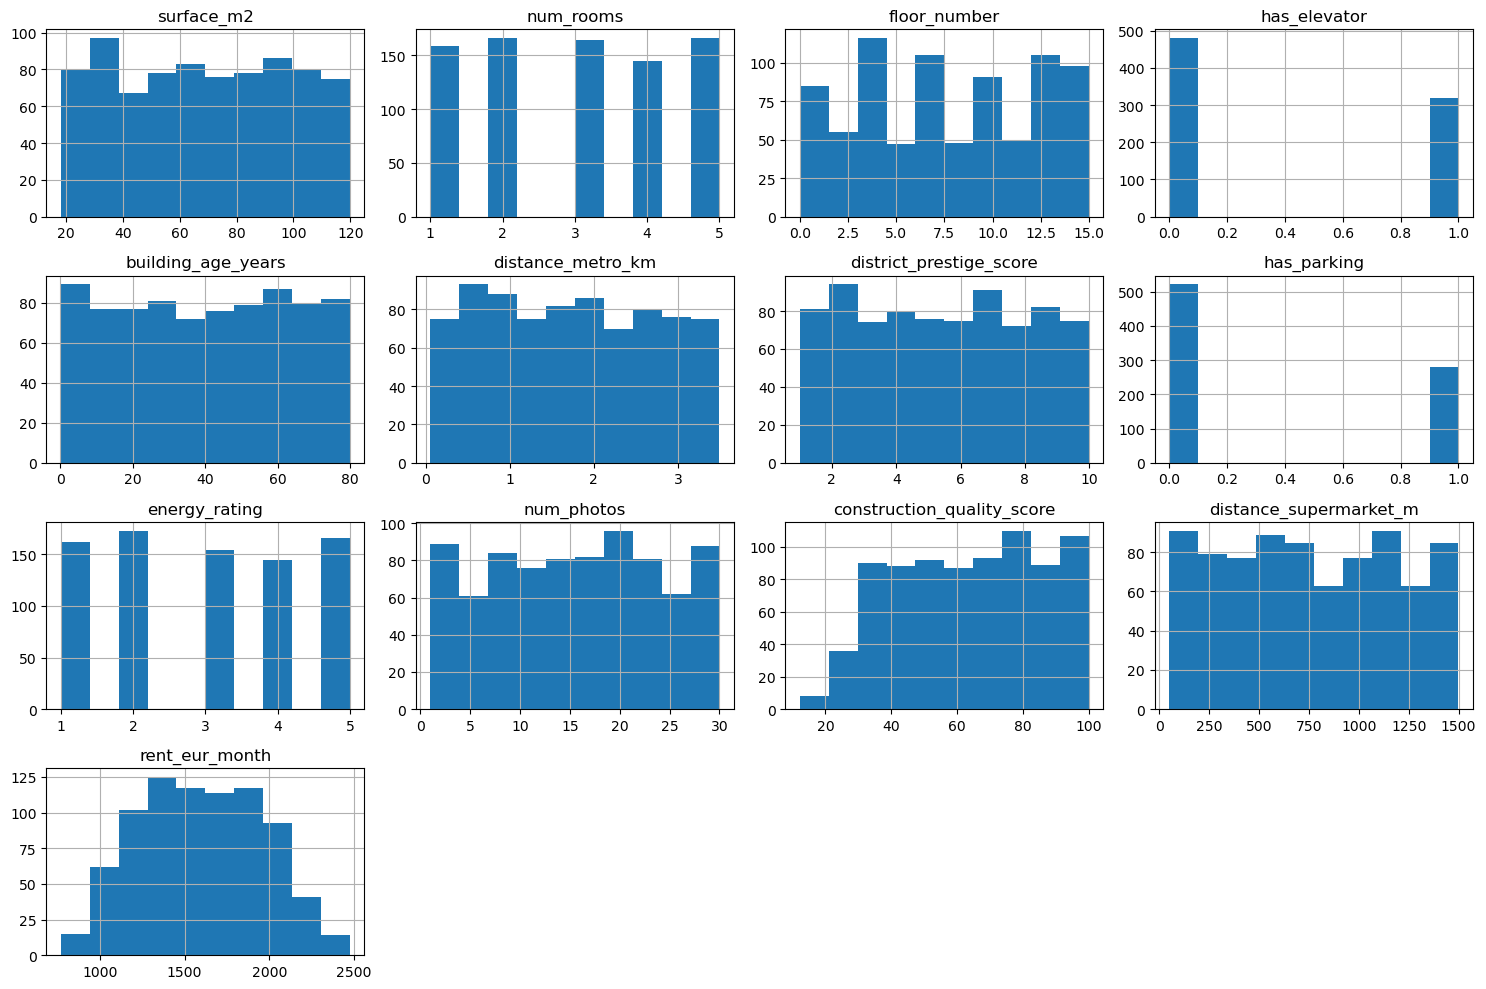

In [ ]:
train_df[numerical_columns].hist(figsize=(15,10))

plt.tight_layout()
plt.show()

## Categorical Features

In [ ]:
categorical_columns = train_df.select_dtypes(include="object").columns
categorical_columns

Index([], dtype='object')

In [ ]:
for col in categorical_columns:
    print("\n")
    print(col)
    print(train_df[col].value_counts())

## Correlation Analysis

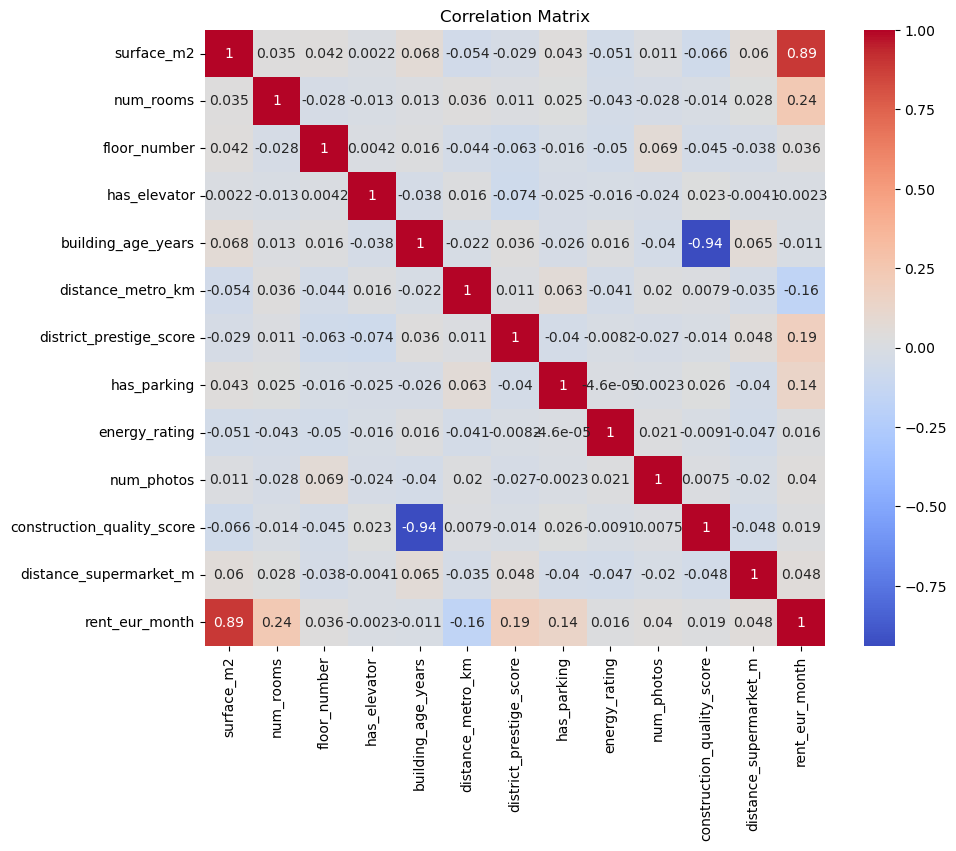

In [ ]:
correlation_matrix = train_df[numerical_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

# surface_m2 has very strong correlation with rent : 0.89 more the apartment is big more the rent is high 
# building_age_years and construction_quality_score negative correlation : -0.94 old buildings have low quality leavings thus negative correlation 

In [ ]:
correlation_with_target = correlation_matrix["rent_eur_month"].sort_values(ascending=False)

correlation_with_target

rent_eur_month                1.000000
surface_m2                    0.891277
num_rooms                     0.240278
district_prestige_score       0.187386
has_parking                   0.142852
distance_supermarket_m        0.048308
num_photos                    0.040131
floor_number                  0.035751
construction_quality_score    0.019385
energy_rating                 0.016475
has_elevator                 -0.002253
building_age_years           -0.010807
distance_metro_km            -0.164211
Name: rent_eur_month, dtype: float64

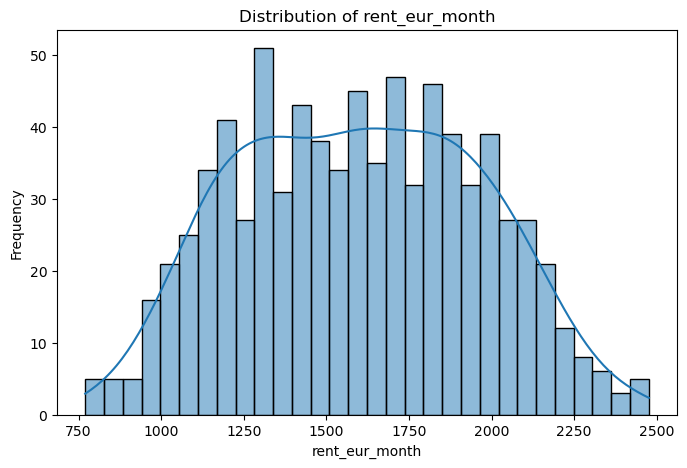

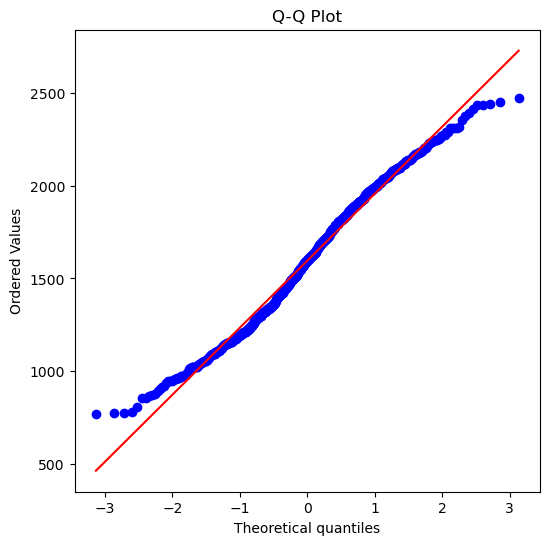

Shapiro-Wilk Test
Statistic: 0.9859203948226449
p-value: 5.870921158750806e-07

Distribution fitting results:

norm
KS Statistic: 0.0513
p-value: 0.0286
------------------------------
expon
KS Statistic: 0.2541
p-value: 0.0000
------------------------------
lognorm
KS Statistic: 0.0484
p-value: 0.0458
------------------------------
gamma
KS Statistic: 0.0496
p-value: 0.0376
------------------------------


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Choose the column you want to study
data = train_df["rent_eur_month"]

# Remove missing values
data = data.dropna()

# Histogram + KDE
plt.figure(figsize=(8,5))
sns.histplot(data, kde=True, bins=30)

plt.title("Distribution of rent_eur_month")
plt.xlabel("rent_eur_month")
plt.ylabel("Frequency")

plt.show()


# Q-Q Plot (checks normality)
plt.figure(figsize=(6,6))
stats.probplot(data, dist="norm", plot=plt)

plt.title("Q-Q Plot")
plt.show()


# Compare with several distributions
distributions = ['norm', 'expon', 'lognorm', 'gamma']

print("\nDistribution fitting results:\n")

for dist_name in distributions:
    dist = getattr(stats, dist_name)

    # Fit distribution parameters
    params = dist.fit(data)

    # Kolmogorov-Smirnov test
    ks_stat, p_value = stats.kstest(data, dist_name, args=params)

    print(f"{dist_name}")
    print(f"KS Statistic: {ks_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    print("-" * 30)

In [ ]:
#Data may be approximately normal. Right-skewed
#Extreme outliers → heavy-tailed distribution. 
#Points close to the straight line → distribution close to normal. Curved shape or large deviations at ends → not normal.